# Intelligent Network Slicing Security
## A Tutorial on Clustering-based Anomaly Detection

**Authors:** Gabriel C. R. Moras · Joao Victor Simoes Rosa · Lucas do Rosario da Silva

---

## Pipeline Overview

This notebook implements a **two-stage hybrid model** for intrusion detection in 5G networks,
following the methodology described in the tutorial paper. The pipeline combines **unsupervised**
learning (K-Means) with **supervised** learning (MLP Classifier) for **multi-class** traffic classification.

```
CICIDS-2017 Dataset
       |
       v
+---------------------+
|  Data Preprocessing |  <- Cleaning, Label Grouping (7 families),
|                     |     Feature Selection, Normalization
+----------+----------+
           |
           v
+---------------------+
|  Data Preparation   |  <- 80 : 10 : 10 Split
|  Train/Val/Test     |     (no data leakage)
+----------+----------+
           |
           |
           v
+---------------------+
|  Data Preprocessing |  <- Resampling only training data
|         1.2         |  
+----------+----------+        

     +-----+------+
     v            v
+---------+  +------------------------+
| Training|  | Clustering Training    |  <- K-Means (K-Means++ init)
|   Set   |->| Pseudo-Label Produce   |
+---------+  | Feature Concatenation  |
             +----------+-------------+
                        |
                        v
             +----------------------+
             | MLP Classifier       |  <- Classifier Training
             | Intrusion Detection  |     & Validation (7 classes)
             +----------------------+
```

### Why multi-class classification?

In 5G Network Slicing environments, identifying **which attack family** is occurring
is just as important as detecting that an attack is happening. Different families require
distinct responses from the slice orchestrator:

- **DoS/DDoS**: immediate slice isolation and rerouting of critical traffic
- **PortScan**: elevated monitoring and reconnaissance blocking
- **Brute Force**: authentication lockout and unauthorized access alert
- **Web Attack**: deep packet inspection at the application layer
- **Bot**: quarantine of the compromised device
- **Infiltration**: network forensics and surgical isolation of the affected slice

A binary model (Benign/Anomaly) does not provide this operational granularity.

### Adopted Class Families

| Family | Mapped Attacks |
|---|---|
| `BENIGN` | Legitimate traffic |
| `DoS/DDoS` | DoS Hulk, DoS GoldenEye, DoS slowloris, DoS Slowhttptest, Heartbleed, DDoS |
| `PortScan` | PortScan |
| `Brute Force` | FTP-Patator, SSH-Patator |
| `Web Attack` | Web Attack - Brute Force, Web Attack - XSS, Web Attack - Sql Injection |
| `Bot` | Bot |
| `Infiltration` | Infiltration |

### Dataset: CICIDS-2017

The **Canadian Institute for Cybersecurity Intrusion Detection System 2017** is one of the most
widely used benchmarks in IDS research. It contains network traffic captured over one week,
with real attacks such as DoS, DDoS, PortScan, Brute Force, and infiltrations.

| Characteristic | Value |
|---|---|
| Files | 8 daily CSVs |
| Raw features | ~78 numerical flow features |
| Total samples | ~2.8 million |
| Raw classes | BENIGN + 14 attack subtypes |
| Classes after grouping | 7 families |

> **Methodological reference:** This pipeline follows the practices described in Yin et al. (2023)
> and Pawar & Deshmukh (2025), adapted to the multi-class Network Slicing context.


---
## Step 0 — Imports and Environment Setup


In [1]:
# ==============================================================================
# IMPORTS
# ==============================================================================
# Data manipulation
import pandas as pd
import numpy as np
import glob
import os
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ── IEEE-publication style ────────────────────────────────────────────────────
plt.rcParams.update({
    # Font
    'font.family'       : 'serif',
    'font.serif'        : ['Times New Roman', 'DejaVu Serif'],
    'font.size'         : 10,
    'axes.titlesize'    : 11,
    'axes.labelsize'    : 10,
    'xtick.labelsize'   : 9,
    'ytick.labelsize'   : 9,
    'legend.fontsize'   : 9,
    'figure.titlesize'  : 12,
    # Lines & markers
    'lines.linewidth'   : 1.5,
    'lines.markersize'  : 6,
    # Axes
    'axes.linewidth'    : 0.8,
    'axes.edgecolor'    : '#333333',
    'axes.facecolor'    : 'white',
    'axes.grid'         : True,
    'grid.color'        : '#cccccc',
    'grid.linewidth'    : 0.5,
    'grid.alpha'        : 0.6,
    # Figure
    'figure.facecolor'  : 'white',
    'figure.dpi'        : 150,       # screen preview
    'savefig.dpi'       : 300,       # saved files
    'savefig.bbox'      : 'tight',
    'savefig.pad_inches': 0.05,
    # Legend
    'legend.framealpha' : 0.9,
    'legend.edgecolor'  : '#cccccc',
    'legend.frameon'    : True,
})

# Colour-blind-safe discrete palette (Paul Tol — 7 categories)
IEEE_PALETTE = {
    'BENIGN'      : '#4477AA',   # blue
    'DoS/DDoS'    : '#CC3311',   # red
    'PortScan'    : '#EE7733',   # orange
    'Brute Force' : '#AA3377',   # purple
    'Web Attack'  : '#009988',   # teal
    'Bot'         : '#BBBBBB',   # grey
    'Infiltration': '#332288',   # dark blue
}
# ─────────────────────────────────────────────────────────────────────────────

# Preprocessing and feature selection
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.feature_selection import mutual_info_classif
from sklearn.utils import resample

# Clustering
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Supervised classifier
from sklearn.neural_network import MLPClassifier

# Evaluation — multi-class requires average='macro' or 'weighted'
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score,
    recall_score, precision_score
)

# Decomposition for visualization
from sklearn.decomposition import PCA

# Used to free RAM after processing large files
import gc

print('Environment configured successfully.')
print(f'   pandas  : {pd.__version__}')
print(f'   numpy   : {np.__version__}')
import sklearn; print(f'   sklearn : {sklearn.__version__}')


Environment configured successfully.
   pandas  : 2.2.2
   numpy   : 1.26.4
   sklearn : 1.5.0


---
## Step 1 — Data Loading and Cleaning

### 1.1 Loading

CICIDS-2017 is distributed across multiple CSV files, one per capture day.
To keep the experiment tractable without losing statistical representativeness, a
**stratified 10% sample from each daily file** is drawn before concatenation.

> **Why 10%?** The full dataset has ~2.8 million records. Using 100% would make
> K-Means and MLP prohibitively slow without a GPU. 10% preserves the class
> distribution of each day and yields ~280k samples — sufficient for robust results.

### 1.2 Cleaning

CICIDS-2017 has two known data quality issues that must be addressed:

1. **Infinite values** (`Inf`, `-Inf`): arise in rate-based features such as
   `Flow Bytes/s` when the flow duration is zero. Replaced with `NaN`.

2. **Missing values** (`NaN`): after the replacement above, **median imputation**
   is applied (robust to outliers) instead of dropping rows.

### 1.3 Family Mapping (Multi-Class)

Unlike binary grouping (Benign/Anomaly), here each attack subtype is mapped to its
**taxonomic family**. CICIDS-2017 contains 14 attack subtypes consolidated into
6 families + BENIGN, totalling **7 classes**.

**Why group into families instead of keeping all 14 subtypes?**
- Subtypes such as `DoS Hulk` and `DoS GoldenEye` share the same attack vector
  (HTTP resource exhaustion), making it redundant to treat them as distinct classes
- Very rare classes (e.g. `Infiltration` with ~36 samples) cause training instability
  if used individually — family grouping preserves them
- Family-level mapping is more operationally actionable: the 5G slice orchestrator
  reacts to threat families, not specific toolsets

```
Raw label              ->  Family
----------------------       ---------
BENIGN               ->  BENIGN
DoS Hulk             \  
DoS GoldenEye         |
DoS slowloris         |->  DoS/DDoS
DoS Slowhttptest      |
Heartbleed            |
DDoS                 /
FTP-Patator          \  ->  Brute Force
SSH-Patator          /
PortScan             ->  PortScan
Web Attack - *       ->  Web Attack  (3 subtypes)
Bot                  ->  Bot
Infiltration         ->  Infiltration
```


In [2]:
import pandas as pd
import numpy as np
import glob
import os
import gc

# ==============================================================================
# STEP 1.1 — OPTIMISED DATA LOADING (WITHOUT CRASHING THE KERNEL)
# ==============================================================================
DATASET_PATH = './MachineLearningCSV'
SAMPLE_FRACTION = 0.10   # 10% of the data
RANDOM_STATE = 42

csv_files = glob.glob(DATASET_PATH + '/*.csv')
print(f'CSV files found: {len(csv_files)}\n')

# Accumulators for invalid-value counts across the full dataset
total_nulls    = 0
total_infinite = 0

# List to store the 10% sample from each file
sampled_dataframes = []

for f in csv_files:
    file_name = os.path.basename(f)
    print(f'Processing: {file_name}...')

    # 1. Load only THIS file into memory
    df_temp = pd.read_csv(f, low_memory=False)

    # IMMEDIATE CLEAN-UP: strip hidden whitespace so the 'Label' column can be used now
    df_temp.columns = df_temp.columns.str.strip()

    # 2. Count nulls in this file and add to the total
    total_nulls += df_temp.isnull().sum().sum()

    # 3. Count infinities in this file and add to the total
    numeric_cols = df_temp.select_dtypes(include=[np.number])
    total_infinite += np.isinf(numeric_cols).sum().sum()

    # 4. STRATIFIED SAMPLING: draw the exact fraction from EACH class present in the file
    # If a class is very rare on a given day, Pandas will attempt to preserve the proportion
    df_sample = df_temp.groupby('Label', group_keys=False).apply(
        lambda x: x.sample(frac=SAMPLE_FRACTION, random_state=RANDOM_STATE)
    )
    sampled_dataframes.append(df_sample)

    # 5. Delete the large file from memory before moving to the next one
    del df_temp
    del numeric_cols
    del df_sample
    gc.collect()  # Force the OS to flush the RAM garbage collector immediately

print('\nAll files processed successfully!')

# ==============================================================================
# INVALID VALUE REPORT (100% OF THE DATA)
# ==============================================================================
print(f'\n--- Invalid Value Report (Across the Full Dataset) ---')
print(f'Null / Missing values (NaN) : {total_nulls:,}')
print(f'Infinite values             : {total_infinite:,}')
print(f'Total invalid               : {total_nulls + total_infinite:,}')
print('-' * 58)

# ==============================================================================
# CONCATENATE THE 10% SAMPLES FOR TRAINING
# ==============================================================================
print(f'\nConcatenating {SAMPLE_FRACTION*100:.0f}% samples from each file...')
combined_df = pd.concat(sampled_dataframes, ignore_index=True)

print(f'\nFinal shape after sampling (ready for use): {combined_df.shape}')
print(f'   Final samples : {combined_df.shape[0]:,}')


CSV files found: 8

Processing: Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv...
Processing: Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv...
Processing: Friday-WorkingHours-Morning.pcap_ISCX.csv...
Processing: Monday-WorkingHours.pcap_ISCX.csv...
Processing: Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv...
Processing: Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv...
Processing: Tuesday-WorkingHours.pcap_ISCX.csv...
Processing: Wednesday-workingHours.pcap_ISCX.csv...

All files processed successfully!

--- Invalid Value Report (Across the Full Dataset) ---
Null / Missing values (NaN) : 1,358
Infinite values             : 4,376
Total invalid               : 5,734
----------------------------------------------------------

Concatenating 10% samples from each file...

Final shape after sampling (ready for use): (283077, 79)
   Final samples : 283,077


In [4]:
# ==============================================================================
# STEP 1.2 — DATA CLEANING
# ==============================================================================
# Remove colunas identificadoras que causariam overfitting ao host especifico
# e nao representam comportamento de rede generalizavel
columns_to_exclude = ['Flow ID', 'Source IP', 'Destination IP', 'Timestamp', 'External IP']
df_cleaned = combined_df.drop(
    columns=[col for col in columns_to_exclude if col in combined_df.columns]
)
# Diagnostic before cleaning
n_inf  = np.isinf(df_cleaned.select_dtypes(include=np.number)).sum().sum()
n_null = df_cleaned.isnull().sum().sum()
print(f'Diagnostic before cleaning:')
print(f'   Inf/-Inf values : {n_inf:,}')
print(f'   NaN values      : {n_null:,}')

# Replace Inf with NaN, then impute with the median
df_cleaned.replace([np.inf, -np.inf], np.nan, inplace=True)
df_cleaned.fillna(df_cleaned.median(numeric_only=True), inplace=True)

print(f'   NaN values after imputation: {df_cleaned.isnull().sum().sum()}')
print(f'\nCleaning complete. Current shape: {df_cleaned.shape}')


Diagnostic before cleaning:
   Inf/-Inf values : 425
   NaN values      : 125
   NaN values after imputation: 0

Cleaning complete. Current shape: (283077, 79)


ORIGINAL label distribution in CICIDS-2017:
Label
BENIGN                        227311
DoS Hulk                       23107
PortScan                       15893
DDoS                           12803
DoS GoldenEye                   1029
FTP-Patator                      794
SSH-Patator                      590
DoS slowloris                    580
DoS Slowhttptest                 550
Bot                              197
Web Attack � Brute Force         151
Web Attack � XSS                  65
Infiltration                       4
Web Attack � Sql Injection         2
Heartbleed                         1

Distribution after family mapping:
Label
BENIGN          227311
DoS/DDoS         38070
PortScan         15893
Brute Force       1384
Web Attack         218
Bot                197
Infiltration         4


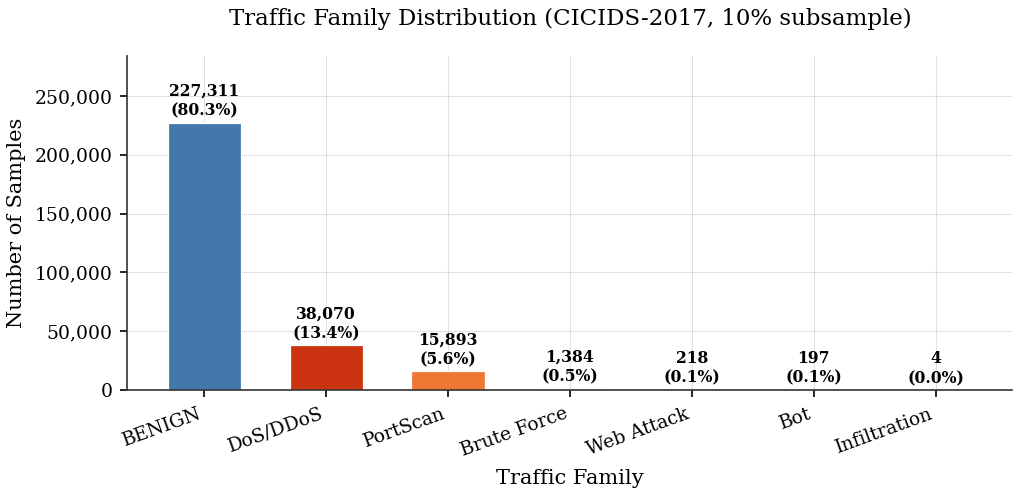

Figure saved: fig1_label_distribution.pdf / .png


In [5]:
# ==============================================================================
# STEP 1.3 — FAMILY MAPPING (Multi-Class: 7 classes)
# ==============================================================================
print('ORIGINAL label distribution in CICIDS-2017:')
print(df_cleaned['Label'].value_counts().to_string())
print()

# Robust mapping function
def map_robust(label):
    # Convert label to uppercase string for safe comparison
    l = str(label).upper()

    if 'BENIGN' in l: return 'BENIGN'

    # Group DoS, DDoS, and Heartbleed (resource-exhaustion DoS variant)
    if any(x in l for x in ['HULK', 'GOLDENEYE', 'LORIS', 'SLOWHTTP', 'DDOS', 'HEARTBLEED']):
        return 'DoS/DDoS'

    if 'PORTSCAN' in l: return 'PortScan'

    # 'PATATOR' covers both SSH-Patator and FTP-Patator
    if 'PATATOR' in l: return 'Brute Force'

    # 'WEB' captures 'Web Attack  Brute Force', 'Web Attack  XSS', etc.
    if 'WEB' in l: return 'Web Attack'

    if 'BOT' in l: return 'Bot'

    if 'INFILTRATION' in l: return 'Infiltration'

    return None  # Unmapped labels become NaN and will be removed

# 1. Apply the mapping
df_cleaned['Label'] = df_cleaned['Label'].apply(map_robust)

# 2. Remove any unmapped labels
n_unmapped = df_cleaned['Label'].isnull().sum()
if n_unmapped > 0:
    print(f'WARNING: {n_unmapped} samples removed (unmapped labels).')
df_cleaned.dropna(subset=['Label'], inplace=True)

# Class order for consistent display across all plots
CLASS_ORDER = ['BENIGN', 'DoS/DDoS', 'PortScan', 'Brute Force', 'Web Attack', 'Bot', 'Infiltration']

# Use the IEEE palette defined in the imports cell
CLASS_COLORS = IEEE_PALETTE

print('Distribution after family mapping:')
label_counts = df_cleaned['Label'].value_counts().reindex(CLASS_ORDER).dropna()
print(label_counts.to_string())

# ── Fig. 1 — Traffic Family Distribution ─────────────────────────────────────
plot_labels = [c for c in CLASS_ORDER if c in label_counts.index]
plot_values = label_counts[plot_labels]
plot_colors = [CLASS_COLORS[c] for c in plot_labels]

fig, ax = plt.subplots(figsize=(7, 3.5))
bars = ax.bar(plot_labels, plot_values, color=plot_colors,
              edgecolor='white', linewidth=0.6, width=0.6)

# AJUSTE: Aumentar o limite superior do eixo Y em 25% para o texto não sobrepor o título
ax.set_ylim(0, max(plot_values) * 1.25)

# Annotate bars with absolute count + percentage
for bar, v in zip(bars, plot_values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + max(plot_values) * 0.012,
        f'{v:,}\n({100 * v / len(df_cleaned):.1f}%)',
        ha='center', va='bottom', fontsize=7.5, fontweight='bold'
    )

ax.set_xlabel('Traffic Family')
ax.set_ylabel('Number of Samples')

# AJUSTE: Aumentado o 'pad' de 8 para 15 para dar mais margem ao título
ax.set_title('Traffic Family Distribution (CICIDS-2017, 10% subsample)',
             pad=15)

# Correção de um Warning comum no matplotlib mais recente: 
# Passar os ticks antes de setar os labels resolve, mas mantive seu formato original.
ax.set_xticks(range(len(plot_labels)))
ax.set_xticklabels(plot_labels, rotation=20, ha='right')

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.set_axisbelow(True)
sns.despine(ax=ax)
plt.tight_layout()
plt.savefig('fig1_label_distribution.pdf')
plt.savefig('fig1_label_distribution.png')
plt.show()
print('Figure saved: fig1_label_distribution.pdf / .png')

---
## Step 2 — Data Splitting (80 : 10 : 10)

The data split **must occur before** feature selection and normalization.
Doing otherwise causes **Data Leakage** — the model 'leaks' information from the
test set into training, artificially inflating the metrics.

**Split adopted:**
- **80% Train** — used to fit the scaler, compute Information Gain, and train the models
- **10% Validation** — used to monitor the MLP and tune hyperparameters
- **10% Test** — used **exactly once** at the end to report final results

The `stratify=y` parameter ensures that the proportion of **all 7 families** is
preserved equally across the three sets — essential for rare classes such as
`Infiltration` and `Bot`, which could disappear entirely from a split without stratification.


In [6]:
# ==============================================================================
# STEP 2 — DATA SPLITTING (80:10:10 Stratified Hold-out)
# ==============================================================================

# SAFETY: stratify requires at least 2 samples per class.
# Remove any class with fewer than 10 samples for methodological soundness.
counts = df_cleaned['Label'].value_counts()
valid_classes = counts[counts >= 10].index
df_cleaned = df_cleaned[df_cleaned['Label'].isin(valid_classes)]

X = df_cleaned.drop(columns=['Label'])
y = df_cleaned['Label']

# First split: 80% train / 20% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

# Second split: 50% of temp -> validation (10%) / test (10%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=RANDOM_STATE, stratify=y_temp
)

print('Data split complete (Zero Data Leakage):')
print(f'   Train      : {X_train.shape[0]:>7,} samples ({100*len(X_train)/len(X):.0f}%)')
print(f'   Validation : {X_val.shape[0]:>7,} samples ({100*len(X_val)/len(X):.0f}%)')
print(f'   Test       : {X_test.shape[0]:>7,} samples ({100*len(X_test)/len(X):.0f}%)')

# Verify that all 7 families are present in all 3 splits
print('\nFamily distribution per split (% within split):')
header = f'  {"Family":<15}' + ''.join(f'  {s:<12}' for s in ['Train', 'Validation', 'Test'])
print(header)
print('  ' + '-' * (len(header) - 2))
for cls in CLASS_ORDER:
    row = f'  {cls:<15}'
    for y_split in [y_train, y_val, y_test]:
        pct = 100 * (y_split == cls).sum() / len(y_split)
        row += f'  {pct:>8.1f}%   '
    print(row)


Data split complete (Zero Data Leakage):
   Train      : 226,458 samples (80%)
   Validation :  28,307 samples (10%)
   Test       :  28,308 samples (10%)

Family distribution per split (% within split):
  Family           Train         Validation    Test        
  ---------------------------------------------------------
  BENIGN               80.3%         80.3%         80.3%   
  DoS/DDoS             13.4%         13.4%         13.4%   
  PortScan              5.6%          5.6%          5.6%   
  Brute Force           0.5%          0.5%          0.5%   
  Web Attack            0.1%          0.1%          0.1%   
  Bot                   0.1%          0.1%          0.1%   
  Infiltration          0.0%          0.0%          0.0%   


---
## Step 3 — Resampling (Class Balancing)

CICIDS-2017 is **severely imbalanced** even after family mapping.
The `BENIGN` family dominates the dataset (~80% of samples), while families such as
`Infiltration` and `Bot` are extremely rare.

In multi-class classification, this imbalance causes two compounding problems:
1. The model learns to predict `BENIGN` almost always, achieving high global accuracy
   but detecting few attacks
2. Minority classes (Infiltration, Bot) virtually disappear from the learning signal

**Strategy adopted — Undersampling combined with minimum floor:**
- The `BENIGN` class is capped at no more than 2x the largest attack class
- Attack classes with fewer than `MIN_SAMPLES` samples receive oversampling
  via `resample(replace=True)` to guarantee minimum representation
- This preserves the signal of rare classes without creating an artificially uniform dataset

> **Why not SMOTE?** SMOTE synthesises samples by linear interpolation in the feature space.
> For network traffic, intermediate samples between two real flows may not correspond to
> any real network behaviour, introducing noise.
> Bootstrap oversampling (replace=True) reuses real samples instead.


In [7]:
# ==============================================================================
# STEP 3 — MULTI-CLASS RESAMPLING (APPLIED TO TRAINING SET ONLY)
# Strategy: undersampling of BENIGN + minimum floor for rare classes
# ==============================================================================
print('Balancing the Training set ONLY...')

# 1. Temporarily merge X_train and y_train for easier manipulation
train_df = pd.concat([X_train, y_train], axis=1)

# Filter CLASS_ORDER to only those classes actually present in training
# This prevents KeyError if a class (e.g. Infiltration) was removed earlier
PRESENT_CLASSES = [c for c in CLASS_ORDER if c in train_df['Label'].unique()]

print('\nTraining distribution BEFORE resampling:')
dist_before = train_df['Label'].value_counts().reindex(PRESENT_CLASSES)
for cls, cnt in dist_before.items():
    print(f'   {cls:<15}: {cnt:>7,} samples')

# Compute the size of the largest ATTACK class (excluding BENIGN) in training
attack_counts = dist_before.drop('BENIGN', errors='ignore')

if not attack_counts.empty:
    max_attack = int(attack_counts.max())
    # Minimum floor for very rare classes
    MIN_SAMPLES = max(500, int(max_attack * 0.10))
else:
    # Fallback if only benign samples exist (safety scenario)
    max_attack = len(train_df)
    MIN_SAMPLES = 500

print(f'\nResampling parameters (computed from training set):')
print(f'   Largest attack class : {max_attack:,} samples')
print(f'   BENIGN ceiling       : {2 * max_attack:,} samples (2x largest attack)')
print(f'   Minority floor       : {MIN_SAMPLES:,} samples')

resampled_dfs = []

# Iterate only over classes that actually have samples in training
for cls in PRESENT_CLASSES:
    df_cls = train_df[train_df['Label'] == cls]
    n_original = len(df_cls)

    if cls == 'BENIGN':
        # Undersampling: cap BENIGN at 2x the largest attack class
        n_target = min(n_original, 2 * max_attack)
        df_resampled = resample(df_cls, replace=False,
                                n_samples=n_target, random_state=RANDOM_STATE)
        action = f'undersample -> {n_target:,}'

    elif n_original < MIN_SAMPLES:
        # Oversampling (bootstrap): duplicate real samples to reach the floor
        df_resampled = resample(df_cls, replace=True,
                                n_samples=MIN_SAMPLES, random_state=RANDOM_STATE)
        action = f'oversample {n_original} -> {MIN_SAMPLES:,}'

    else:
        # Keep the class as-is
        df_resampled = df_cls
        action = f'unchanged ({n_original:,})'

    resampled_dfs.append(df_resampled)
    print(f'   {cls:<15}: {action}')

# Concatenate and shuffle the balanced training set
train_balanced = pd.concat(resampled_dfs, ignore_index=True)
train_balanced = train_balanced.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

# 2. Overwrite the original training variables
# This ensures Step 4 (Information Gain) uses the balanced data
X_train = train_balanced.drop(columns=['Label'])
y_train = train_balanced['Label']

print(f'\nTraining distribution AFTER resampling:')
dist_after = y_train.value_counts().reindex(PRESENT_CLASSES)
for cls, cnt in dist_after.items():
    print(f'   {cls:<15}: {cnt:>7,} samples ({100*cnt/len(y_train):.1f}%)')
print(f'\nBalanced training set. Shape: {X_train.shape}')


Balancing the Training set ONLY...

Training distribution BEFORE resampling:
   BENIGN         : 181,849 samples
   DoS/DDoS       :  30,456 samples
   PortScan       :  12,714 samples
   Brute Force    :   1,107 samples
   Web Attack     :     174 samples
   Bot            :     158 samples

Resampling parameters (computed from training set):
   Largest attack class : 30,456 samples
   BENIGN ceiling       : 60,912 samples (2x largest attack)
   Minority floor       : 3,045 samples
   BENIGN         : undersample -> 60,912
   DoS/DDoS       : unchanged (30,456)
   PortScan       : unchanged (12,714)
   Brute Force    : oversample 1107 -> 3,045
   Web Attack     : oversample 174 -> 3,045
   Bot            : oversample 158 -> 3,045

Training distribution AFTER resampling:
   BENIGN         :  60,912 samples (53.8%)
   DoS/DDoS       :  30,456 samples (26.9%)
   PortScan       :  12,714 samples (11.2%)
   Brute Force    :   3,045 samples (2.7%)
   Web Attack     :   3,045 samples (2.7%)


---
## Step 4 — Feature Selection and Normalization

### 4.1 Information Gain (Mutual Information)

**Information Gain** measures the statistical dependence between each feature and the target label.
In multi-class classification, `mutual_info_classif` from sklearn computes the average weighted
information gain across all 7 families — features useful for distinguishing any pair of classes
receive a high score.

**Cut-off criterion:** features with Information Gain > 0.05 are retained.

### 4.2 MinMax Normalization

K-Means and MLP are both **scale-sensitive**. Without normalization, features with large values
dominate the Euclidean distance computation in K-Means.

**MinMax normalization** transforms all values to the $[0, 1]$ range:

$$x_{norm} = \\frac{x - x_{min}}{x_{max} - x_{min}}$$

The scaler is **fitted on the training set only** and applied to the others
via `.transform()` — avoiding Data Leakage.


Computing Information Gain on the training set...
(This may take a few seconds...)

Feature selection complete:
   Original features               : 78
   Selected features (IG>0.05) : 60
   Removed features                : 18


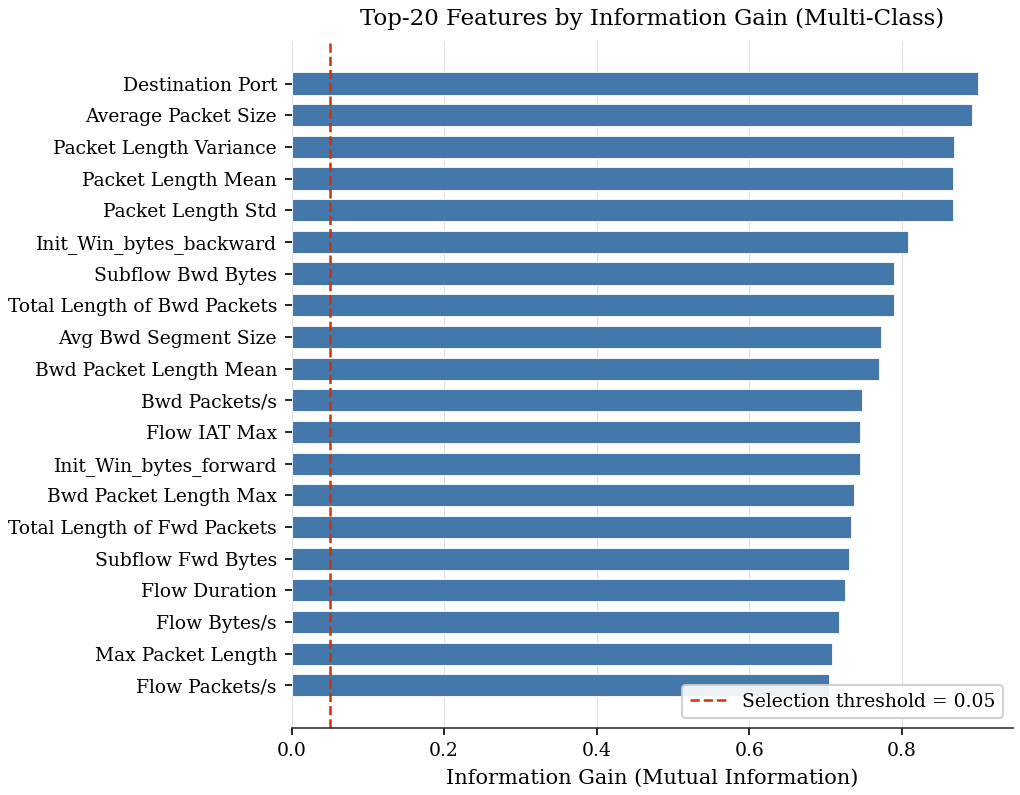

Figure saved: fig2_information_gain.pdf / .png


In [8]:
# ==============================================================================
# STEP 4.1 — FEATURE SELECTION (Information Gain / Mutual Information)
# ==============================================================================
print('Computing Information Gain on the training set...')
print('(This may take a few seconds...)')

importances = mutual_info_classif(X_train, y_train, random_state=RANDOM_STATE)
feature_importance = pd.Series(importances, index=X_train.columns).sort_values(ascending=False)

IG_THRESHOLD = 0.05
selected_features = feature_importance[feature_importance > IG_THRESHOLD].index.tolist()

print(f'\nFeature selection complete:')
print(f'   Original features               : {len(X_train.columns)}')
print(f'   Selected features (IG>{IG_THRESHOLD}) : {len(selected_features)}')
print(f'   Removed features                : {len(X_train.columns) - len(selected_features)}')

# ── Fig. 2 — Top-20 Features by Information Gain ─────────────────────────────
top20 = feature_importance.head(20)

fig, ax = plt.subplots(figsize=(7, 5.5))

# Colour bars by threshold: above = selected (blue), below = discarded (grey)
bar_colors = ['#4477AA' if v > IG_THRESHOLD else '#BBBBBB' for v in top20.values[::-1]]
bars = ax.barh(top20.index[::-1], top20.values[::-1],
               color=bar_colors, edgecolor='white', linewidth=0.4, height=0.7)

ax.axvline(x=IG_THRESHOLD, color='#CC3311', linestyle='--',
           linewidth=1.2, label=f'Selection threshold = {IG_THRESHOLD}')

ax.set_xlabel('Information Gain (Mutual Information)')
ax.set_title('Top-20 Features by Information Gain (Multi-Class)', pad=8)
ax.legend(loc='lower right')
ax.set_axisbelow(True)
sns.despine(ax=ax, left=True)
ax.xaxis.grid(True)
ax.yaxis.grid(False)
plt.tight_layout()
plt.savefig('fig2_information_gain.pdf')
plt.savefig('fig2_information_gain.png')
plt.show()
print('Figure saved: fig2_information_gain.pdf / .png')


In [9]:
# ==============================================================================
# STEP 4.2 — MinMax Scaler NORMALIZATION
# ==============================================================================
X_train_sel = X_train[selected_features]
X_val_sel   = X_val[selected_features]
X_test_sel  = X_test[selected_features]

# Fit ONLY on training set — transform the others (prevents Data Leakage)
scaler = MinMaxScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train_sel), columns=selected_features, index=X_train.index
)
X_val_scaled = pd.DataFrame(
    scaler.transform(X_val_sel), columns=selected_features, index=X_val.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test_sel), columns=selected_features, index=X_test.index
)

print(f'Normalization complete.')
print(f'   Normalized training shape: {X_train_scaled.shape}')
print(f'   Range: [{X_train_scaled.values.min():.4f}, {X_train_scaled.values.max():.4f}]')


Normalization complete.
   Normalized training shape: (113217, 60)
   Range: [0.0000, 1.0000]


---
## Step 5 — Optimal K Selection for K-Means

Before training K-Means, the ideal number of clusters **K** is determined using two methods:

### Elbow Method
Computes the **inertia** (sum of squared distances from each point to its centroid)
for different values of K. The point where the curve 'bends' indicates the optimal K.

### Silhouette Score
Measures how well each point fits within its cluster relative to neighbouring clusters.
Ranges from -1 to 1, where values close to 1 indicate well-separated clusters.

> **Why K=7?** With 7 traffic families, the natural value of K is 7 — one cluster
> per family. In practice, families with similar behaviour (e.g. different DoS subtypes)
> may merge into a single cluster, and the Elbow may suggest a lower K.
> **Inspect the plots and adjust `OPTIMAL_K` according to the observed elbow.**
> Testing K between 4 and 10 is good practice for this dataset.


Computing Elbow and Silhouette Score (subsample: 20,000 points)...
  K |        Inertia |   Silhouette
-----------------------------------
  2 |          18502 |       0.5439
  3 |          12395 |       0.4476
  4 |           9588 |       0.4917
  5 |           7696 |       0.5440
  6 |           6216 |       0.5555
  7 |           4931 |       0.5867
  8 |           4197 |       0.6080
  9 |           3859 |       0.6120
 10 |           3543 |       0.5747
 11 |           3386 |       0.5682

Computation complete.


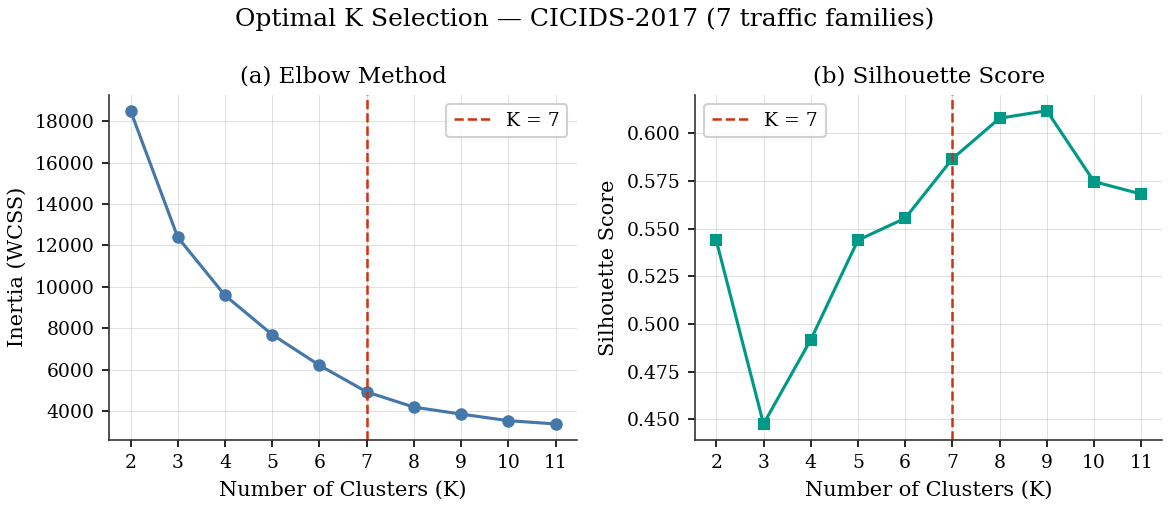

Figure saved: fig3_elbow_silhouette.pdf / .png


In [10]:
# ==============================================================================
# STEP 5 — ELBOW METHOD + SILHOUETTE SCORE
# ==============================================================================
ELBOW_SAMPLE = min(20000, len(X_train_scaled))
idx_sample = np.random.RandomState(RANDOM_STATE).choice(
    len(X_train_scaled), ELBOW_SAMPLE, replace=False
)
X_elbow = X_train_scaled.values[idx_sample]

K_RANGE = range(2, 12)
inertias          = []
silhouette_scores = []

print(f'Computing Elbow and Silhouette Score (subsample: {ELBOW_SAMPLE:,} points)...')
print(f'{"K":>3} | {"Inertia":>14} | {"Silhouette":>12}')
print('-' * 35)

for k in K_RANGE:
    km_tmp = KMeans(n_clusters=k, init='k-means++', n_init=10,
                    max_iter=300, random_state=RANDOM_STATE)
    km_tmp.fit(X_elbow)
    inertias.append(km_tmp.inertia_)

    n_unique = len(np.unique(km_tmp.labels_))
    if n_unique < 2:
        silhouette_scores.append(0.0)
        print(f'{k:>3} | {km_tmp.inertia_:>14.0f} | {"N/A":>12}')
    else:
        sil = silhouette_score(X_elbow, km_tmp.labels_,
                               sample_size=5000, random_state=RANDOM_STATE)
        silhouette_scores.append(sil)
        print(f'{k:>3} | {km_tmp.inertia_:>14.0f} | {sil:>12.4f}')

print('\nComputation complete.')

# ── Fig. 3 — Elbow Method and Silhouette Score ────────────────────────────────
K_LIST = list(K_RANGE)
SELECTED_K = 7

fig, axes = plt.subplots(1, 2, figsize=(8, 3.5))

# ── left: Elbow ──
axes[0].plot(K_LIST, inertias, 'o-', color='#4477AA', linewidth=1.5, markersize=5)
axes[0].axvline(x=SELECTED_K, color='#CC3311', linestyle='--',
                linewidth=1.2, label=f'K = {SELECTED_K}')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia (WCSS)')
axes[0].set_title('(a) Elbow Method')
axes[0].legend()
axes[0].set_xticks(K_LIST)
axes[0].set_axisbelow(True)
sns.despine(ax=axes[0])

# ── right: Silhouette ──
axes[1].plot(K_LIST, silhouette_scores, 's-', color='#009988', linewidth=1.5, markersize=5)
axes[1].axvline(x=SELECTED_K, color='#CC3311', linestyle='--',
                linewidth=1.2, label=f'K = {SELECTED_K}')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('(b) Silhouette Score')
axes[1].legend()
axes[1].set_xticks(K_LIST)
axes[1].set_axisbelow(True)
sns.despine(ax=axes[1])

fig.suptitle('Optimal K Selection — CICIDS-2017 (7 traffic families)')
plt.tight_layout()
plt.savefig('fig3_elbow_silhouette.pdf')
plt.savefig('fig3_elbow_silhouette.png')
plt.show()
print('Figure saved: fig3_elbow_silhouette.pdf / .png')


---
## Step 6 — K-Means Training and Pseudo-Label Generation

### 6.1 K-Means Training

We use **K-Means++** initialization (`init='k-means++'`), which places initial centroids
intelligently — spreading them as far apart as possible.
This accelerates convergence and reduces the risk of poor local minima compared to
random initialization.

### 6.2 Pseudo-Labels and Feature Concatenation

The cluster ID assigned to each flow is added as a new column `Pseudo_Label`.

**Intuition in the multi-class context:** with 7 families, K-Means has the opportunity
to spatially separate families with distinct traffic patterns (e.g. PortScan generates
many short flows, while DoS generates long high-rate flows).
The pseudo-label encapsulates this feature-space geometry, providing the MLP with an
unsupervised 'pre-classification' that refines its decision boundaries.

```
X_train_scaled  (n selected features)
         +
Pseudo_Label    (1 feature: cluster ID = 0 to K-1)
         =
X_train_hybrid  (n+1 features) -> MLP input (7 output classes)
```


In [11]:
# ==============================================================================
# STEP 6.1 — FINAL K-MEANS TRAINING
# ==============================================================================
# Adjust OPTIMAL_K based on the elbow observed in the Step 5 plots.
# The initial value of 7 corresponds to the number of defined traffic families.
OPTIMAL_K = 7

kmeans = KMeans(
    n_clusters=OPTIMAL_K,
    init='k-means++',   # Smart initialization (avoids poor local minima)
    n_init=10,          # 10 independent runs; keep the best result
    max_iter=300,       # Maximum iterations per run
    random_state=RANDOM_STATE
)

print(f'Training K-Means with K={OPTIMAL_K}...')
kmeans.fit(X_train_scaled)

print(f'K-Means trained.')
print(f'   Final inertia    : {kmeans.inertia_:.2f}')
print(f'   Iterations used  : {kmeans.n_iter_}')

pseudo_train = kmeans.predict(X_train_scaled)
unique, counts = np.unique(pseudo_train, return_counts=True)
print(f'\nCluster distribution on training set ({OPTIMAL_K} clusters):')
for u, c in zip(unique, counts):
    print(f'   Cluster {u}: {c:>7,} samples ({100*c/len(pseudo_train):.1f}%)')


Training K-Means with K=7...
K-Means trained.
   Final inertia    : 28178.54
   Iterations used  : 4

Cluster distribution on training set (7 clusters):
   Cluster 0:  30,051 samples (26.5%)
   Cluster 1:  29,344 samples (25.9%)
   Cluster 2:   9,455 samples (8.4%)
   Cluster 3:   6,765 samples (6.0%)
   Cluster 4:  27,704 samples (24.5%)
   Cluster 5:   5,020 samples (4.4%)
   Cluster 6:   4,878 samples (4.3%)


In [12]:
# ==============================================================================
# STEP 6.2 — PSEUDO-LABELS AND FEATURE CONCATENATION
# ==============================================================================
pseudo_val  = kmeans.predict(X_val_scaled)
pseudo_test = kmeans.predict(X_test_scaled)

X_train_hybrid = X_train_scaled.copy(); X_train_hybrid['Pseudo_Label'] = pseudo_train
X_val_hybrid   = X_val_scaled.copy();   X_val_hybrid['Pseudo_Label']   = pseudo_val
X_test_hybrid  = X_test_scaled.copy();  X_test_hybrid['Pseudo_Label']  = pseudo_test

print(f'Pseudo-labels concatenated successfully.')
print(f'   Features before : {X_train_scaled.shape[1]}')
print(f'   Features now    : {X_train_hybrid.shape[1]} (+1 Pseudo_Label)')


Pseudo-labels concatenated successfully.
   Features before : 60
   Features now    : 61 (+1 Pseudo_Label)


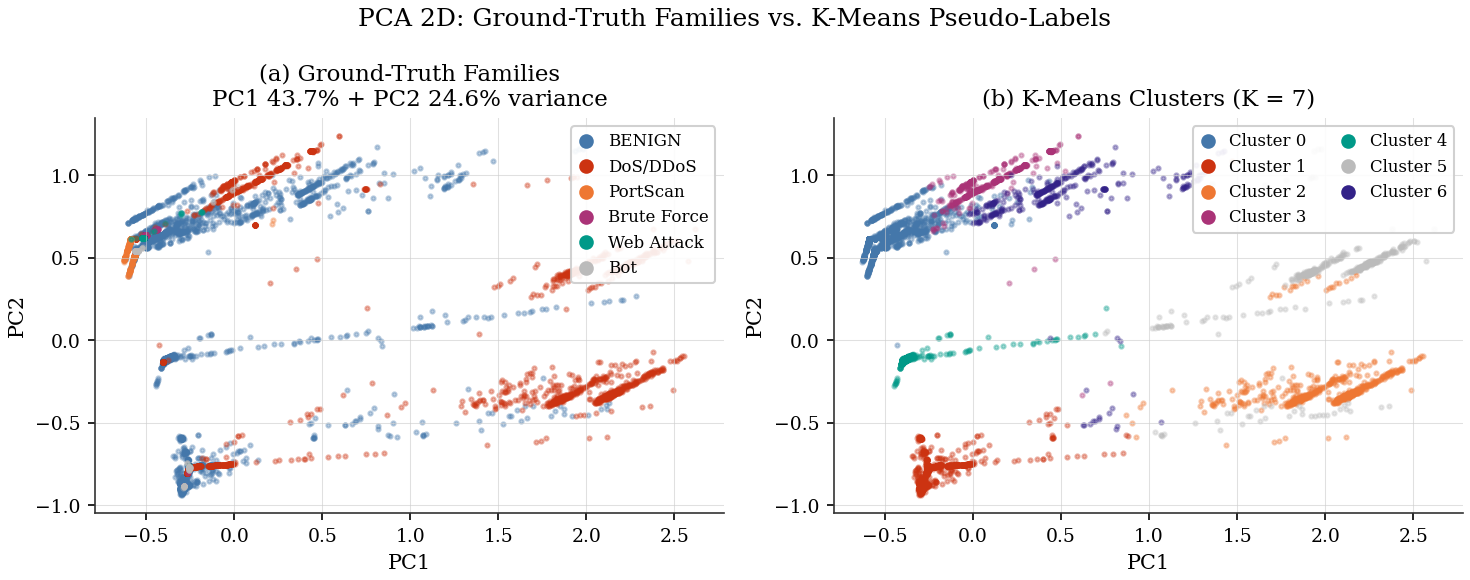

Figure saved: fig4_pca_clusters.pdf / .png


In [13]:
# ==============================================================================
# VISUALIZATION — Fig. 4: PCA 2D — Real Families vs. K-Means Clusters
# ==============================================================================
VIZ_SAMPLE = 8000
idx_viz = np.random.RandomState(RANDOM_STATE).choice(len(X_train_scaled), VIZ_SAMPLE, replace=False)
X_viz = X_train_scaled.values[idx_viz]
y_viz = y_train.values[idx_viz]
c_viz = pseudo_train[idx_viz]

pca  = PCA(n_components=2, random_state=RANDOM_STATE)
X_2d = pca.fit_transform(X_viz)
var  = pca.explained_variance_ratio_

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# ── left: Real families ──
for cls in CLASS_ORDER:
    if cls not in y_viz:
        continue
    mask = y_viz == cls
    axes[0].scatter(X_2d[mask, 0], X_2d[mask, 1],
                    c=CLASS_COLORS[cls], alpha=0.35, s=4, label=cls,
                    rasterized=True)
axes[0].set_title(f'(a) Ground-Truth Families\n'
                  f'PC1 {var[0]*100:.1f}% + PC2 {var[1]*100:.1f}% variance')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
leg0 = axes[0].legend(markerscale=3, fontsize=8, loc='upper right',
                      handlelength=1, handleheight=0.8)
for h in leg0.legend_handles:
    h.set_alpha(1.0)
sns.despine(ax=axes[0])

# ── right: K-Means clusters ──
# Use a distinguishable fixed palette for clusters
CLUSTER_COLORS = ['#4477AA','#CC3311','#EE7733','#AA3377',
                  '#009988','#BBBBBB','#332288']
for k in range(OPTIMAL_K):
    mask = c_viz == k
    axes[1].scatter(X_2d[mask, 0], X_2d[mask, 1],
                    color=CLUSTER_COLORS[k % len(CLUSTER_COLORS)],
                    alpha=0.35, s=4, label=f'Cluster {k}',
                    rasterized=True)
axes[1].set_title(f'(b) K-Means Clusters (K = {OPTIMAL_K})')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
leg1 = axes[1].legend(markerscale=3, fontsize=8, loc='upper right',
                      ncol=2, handlelength=1, handleheight=0.8)
for h in leg1.legend_handles:
    h.set_alpha(1.0)
sns.despine(ax=axes[1])

fig.suptitle('PCA 2D: Ground-Truth Families vs. K-Means Pseudo-Labels')
plt.tight_layout()
plt.savefig('fig4_pca_clusters.pdf')
plt.savefig('fig4_pca_clusters.png')
plt.show()
print('Figure saved: fig4_pca_clusters.pdf / .png')


---
## Step 7 — MLP Classifier Training

The **Multi-Layer Perceptron (MLP)** is the supervised phase of the hybrid model.
It receives the normalized features **enriched with the K-Means pseudo-label**
and learns the decision boundaries between the **7 traffic families**.

### Architecture

```
Input: n+1 features (n selected + 1 Pseudo_Label)
    |
    v
Hidden Layer 1: 128 neurons (ReLU)
    |
    v
Hidden Layer 2: 64 neurons (ReLU)
    |
    v
Hidden Layer 3: 32 neurons (ReLU)
    |
    v
Output: 7 classes (Softmax)
```

**Why 3 layers for multi-class?** The 7-class problem is more complex than binary.
An extra layer (128 neurons) allows the MLP to learn richer intermediate representations
before the specialization layers (64 and 32).

**Why ReLU?** Avoids the vanishing gradient problem present in sigmoids,
accelerates convergence, and is computationally efficient.

**Why Adam?** The Adam optimizer adapts the learning rate individually
for each parameter, making it more robust than SGD for this type of problem.

**Early Stopping:** training halts automatically when the validation loss
does not improve for 15 consecutive epochs — preventing overfitting without
needing to set the number of epochs manually.


In [14]:
# ==============================================================================
# STEP 7 — MLP CLASSIFIER TRAINING (Multi-Class: 7 families)
# ==============================================================================
print('Starting MLP Classifier training...')
n_input   = X_train_hybrid.shape[1]
n_classes = len(CLASS_ORDER)
print(f'Architecture: {n_input} -> 128 -> 64 -> 32 -> {n_classes} classes\n')

mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32),  # 3 layers: greater capacity for 7 classes
    activation='relu',                 # ReLU: avoids vanishing gradient
    solver='adam',                     # Adaptive optimizer
    max_iter=300,                      # Maximum epochs
    random_state=RANDOM_STATE,
    early_stopping=True,               # Stop if validation does not improve
    validation_fraction=0.1,           # 10% of training for internal early stopping
    n_iter_no_change=15,               # Patience: 15 epochs without improvement -> stop
    verbose=True
)


Starting MLP Classifier training...
Architecture: 61 -> 128 -> 64 -> 32 -> 7 classes



In [15]:
mlp.fit(X_train_hybrid, y_train)


Iteration 1, loss = 0.45992112
Validation score: 0.913266
Iteration 2, loss = 0.21193661
Validation score: 0.936054
Iteration 3, loss = 0.15732956
Validation score: 0.953188
Iteration 4, loss = 0.13763042
Validation score: 0.943915
Iteration 5, loss = 0.12928529
Validation score: 0.956103
Iteration 6, loss = 0.12238938
Validation score: 0.956545
Iteration 7, loss = 0.11670137
Validation score: 0.958046
Iteration 8, loss = 0.11115576
Validation score: 0.961138
Iteration 9, loss = 0.10675667
Validation score: 0.961226
Iteration 10, loss = 0.10217866
Validation score: 0.965995
Iteration 11, loss = 0.09711459
Validation score: 0.968645
Iteration 12, loss = 0.09137748
Validation score: 0.967850
Iteration 13, loss = 0.08763299
Validation score: 0.965024
Iteration 14, loss = 0.08350089
Validation score: 0.975623
Iteration 15, loss = 0.07962479
Validation score: 0.975888
Iteration 16, loss = 0.07982257
Validation score: 0.972531
Iteration 17, loss = 0.07556729
Validation score: 0.975004
Iterat

MLPClassifier(early_stopping=True, hidden_layer_sizes=(128, 64, 32),
              max_iter=300, n_iter_no_change=15, random_state=42, verbose=True)

Training complete in 67 epochs.

Results on the VALIDATION set:
    Accuracy   : 0.9760
    F1-Macro   : 0.7405  <- primary metric (no phantom classes)
    F1-Weighted: 0.9790

              precision    recall  f1-score   support

      BENIGN     0.9995    0.9710    0.9850     22731
    DoS/DDoS     0.9632    0.9961    0.9793      3807
    PortScan     0.8383    0.9981    0.9112      1589
 Brute Force     0.9648    0.9928    0.9786       138
  Web Attack     0.2157    1.0000    0.3548        22
         Bot     0.1325    1.0000    0.2339        20

    accuracy                         0.9760     28307
   macro avg     0.6856    0.9930    0.7405     28307
weighted avg     0.9841    0.9760    0.9790     28307



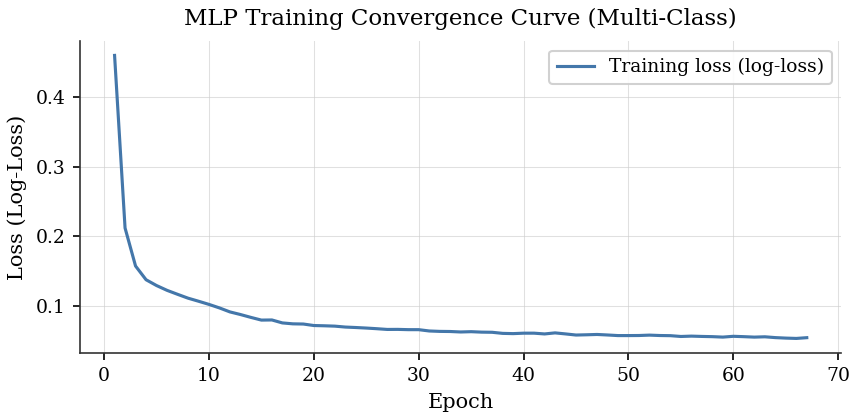

Figure saved: fig5_mlp_convergence.pdf / .png


In [16]:
val_preds = mlp.predict(X_val_hybrid)

ACTUAL_LABELS = [c for c in CLASS_ORDER if c in mlp.classes_]

val_accuracy  = accuracy_score(y_val, val_preds)
val_f1_macro  = f1_score(y_val, val_preds, labels=ACTUAL_LABELS, average='macro', zero_division=0)
val_f1_weight = f1_score(y_val, val_preds, labels=ACTUAL_LABELS, average='weighted', zero_division=0)

print(f'Training complete in {mlp.n_iter_} epochs.')
print(f'\nResults on the VALIDATION set:')
print(f'    Accuracy   : {val_accuracy:.4f}')
print(f'    F1-Macro   : {val_f1_macro:.4f}  <- primary metric (no phantom classes)')
print(f'    F1-Weighted: {val_f1_weight:.4f}')
print(f'\n{classification_report(y_val, val_preds, labels=ACTUAL_LABELS, digits=4, zero_division=0)}')

# ── Fig. 5 — MLP Training Convergence ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 3))

epochs = range(1, len(mlp.loss_curve_) + 1)
ax.plot(epochs, mlp.loss_curve_, color='#4477AA', linewidth=1.5,
        label='Training loss (log-loss)')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss (Log-Loss)')
ax.set_title('MLP Training Convergence Curve (Multi-Class)', pad=8)
ax.legend()
ax.set_axisbelow(True)
sns.despine(ax=ax)
plt.tight_layout()
plt.savefig('fig5_mlp_convergence.pdf')
plt.savefig('fig5_mlp_convergence.png')
plt.show()
print('Figure saved: fig5_mlp_convergence.pdf / .png')


---
## Step 8 — Final Evaluation on the Test Set

This is the definitive evaluation — the test set is used **exactly once**, only here.

### Reported metrics

| Metric | Computation | Interpretation |
|---|---|---|
| **Accuracy** | Correct / Total | Overall proportion of correct predictions |
| **F1-Macro** | Unweighted mean of per-class F1 | Treats all families equally — **primary metric** |
| **F1-Weighted** | Support-weighted mean | Favours larger classes |
| **Precision (per class)** | TP / (TP + FP) | How many alerts were true attacks? |
| **Recall (per class)** | TP / (TP + FN) | How many real attacks were detected? |

> **Why is F1-Macro the primary metric?** In multi-class IDS with imbalanced classes,
> F1-Macro penalises errors on `Infiltration` (rare but critical) and `DoS/DDoS`
> (common) equally. F1-Weighted would mask poor performance on minority classes by
> weighting them less — yet these are exactly the operationally most important classes.


FINAL RESULTS — TEST SET

  Accuracy                : 0.9761 (97.61%)
  F1-Macro  (primary)     : 0.7409  <- (no pruned classes)
  F1-Weighted             : 0.9791
  Precision-Macro         : 0.6869
  Recall-Macro            : 0.9749

              precision    recall  f1-score   support

      BENIGN     0.9990    0.9717    0.9852     22731
    DoS/DDoS     0.9685    0.9940    0.9811      3807
    PortScan     0.8302    0.9962    0.9057      1590
 Brute Force     0.9580    0.9856    0.9716       139
  Web Attack     0.2500    0.9545    0.3962        22
         Bot     0.1154    0.9474    0.2057        19

    accuracy                         0.9761     28308
   macro avg     0.6869    0.9749    0.7409     28308
weighted avg     0.9840    0.9761    0.9791     28308



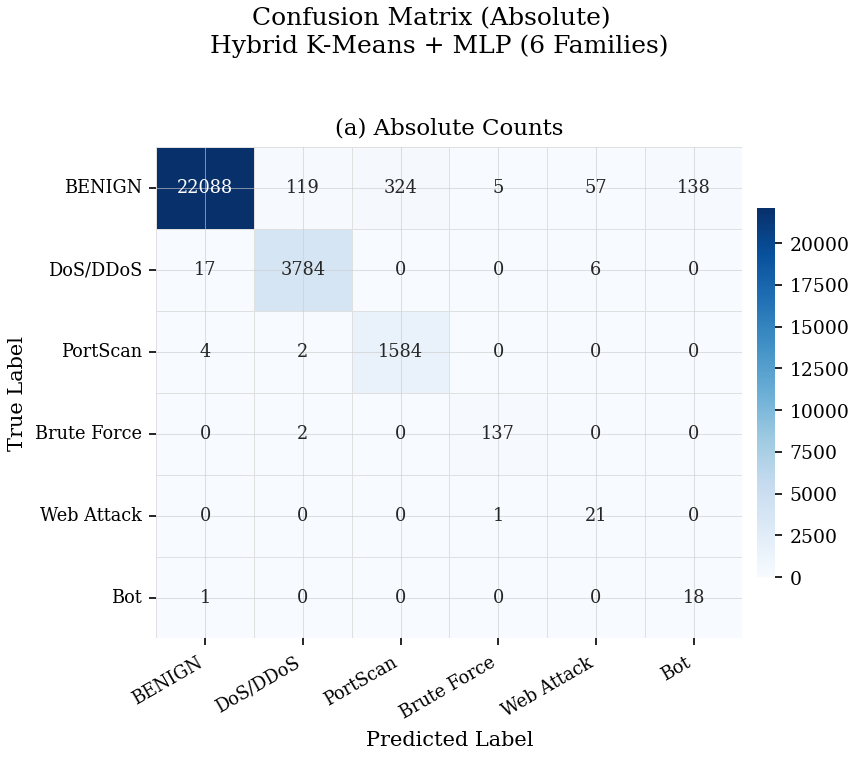

Figure 6a saved: fig6a_confusion_matrix_absolute.pdf / .png


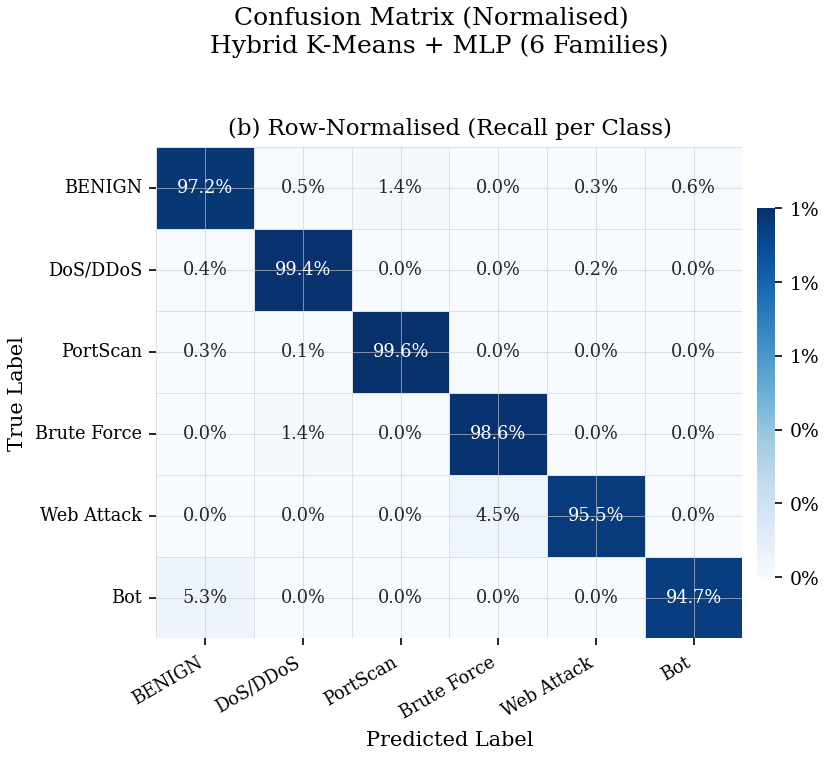

Figure 6b saved: fig6b_confusion_matrix_normalised.pdf / .png


In [17]:
# ==============================================================================
# STEP 8 — FINAL EVALUATION ON THE TEST SET (Dynamic Multi-Class)
# ==============================================================================
print('=' * 65)
print('FINAL RESULTS — TEST SET')
print('=' * 65)

test_preds = mlp.predict(X_test_hybrid)

ACTUAL_LABELS = [c for c in CLASS_ORDER if c in mlp.classes_]

test_accuracy    = accuracy_score(y_test, test_preds)
test_f1_macro    = f1_score(y_test, test_preds, labels=ACTUAL_LABELS, average='macro',    zero_division=0)
test_f1_weighted = f1_score(y_test, test_preds, labels=ACTUAL_LABELS, average='weighted', zero_division=0)
test_rec_macro   = recall_score(y_test, test_preds, labels=ACTUAL_LABELS, average='macro',    zero_division=0)
test_prec_macro  = precision_score(y_test, test_preds, labels=ACTUAL_LABELS, average='macro', zero_division=0)

print(f'\n  Accuracy                : {test_accuracy:.4f} ({test_accuracy*100:.2f}%)')
print(f'  F1-Macro  (primary)     : {test_f1_macro:.4f}  <- (no pruned classes)')
print(f'  F1-Weighted             : {test_f1_weighted:.4f}')
print(f'  Precision-Macro         : {test_prec_macro:.4f}')
print(f'  Recall-Macro            : {test_rec_macro:.4f}')
print(f'\n{classification_report(y_test, test_preds, labels=ACTUAL_LABELS, digits=4, zero_division=0)}')

# ── Fig. 6 — Confusion Matrices ───────────────────────────────────────────────
cm      = confusion_matrix(y_test, test_preds, labels=ACTUAL_LABELS)
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

N   = len(ACTUAL_LABELS)

_annot_kw = {'size': 8.5}
_tick_kw  = {'rotation': 30, 'ha': 'right', 'fontsize': 8.5}

# ==========================================
# Gráfico 1: Absolute Counts
# ==========================================
fig_a, ax_a = plt.subplots(figsize=(6, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=ACTUAL_LABELS, yticklabels=ACTUAL_LABELS,
            linewidths=0.4, linecolor='#e0e0e0',
            ax=ax_a, annot_kws=_annot_kw,
            cbar_kws={'shrink': 0.75, 'pad': 0.02})

ax_a.set_xlabel('Predicted Label')
ax_a.set_ylabel('True Label')
ax_a.set_title('(a) Absolute Counts')
ax_a.set_xticklabels(ACTUAL_LABELS, **_tick_kw)
ax_a.set_yticklabels(ACTUAL_LABELS, rotation=0, fontsize=8.5)

fig_a.suptitle(f'Confusion Matrix (Absolute) \n Hybrid K-Means + MLP ({N} Families)', y=1.02)
plt.tight_layout()
plt.savefig('fig6a_confusion_matrix_absolute.pdf')
plt.savefig('fig6a_confusion_matrix_absolute.png')
plt.show()
print('Figure 6a saved: fig6a_confusion_matrix_absolute.pdf / .png')

# ==========================================
# Gráfico 2: Row-Normalised
# ==========================================
fig_b, ax_b = plt.subplots(figsize=(6, 5))

sns.heatmap(cm_norm, annot=True, fmt='.1%', cmap='Blues',
            xticklabels=ACTUAL_LABELS, yticklabels=ACTUAL_LABELS,
            linewidths=0.4, linecolor='#e0e0e0',
            ax=ax_b, annot_kws=_annot_kw,
            vmin=0, vmax=1,
            cbar_kws={'shrink': 0.75, 'pad': 0.02, 'format': '%.0f%%'})

ax_b.set_xlabel('Predicted Label')
ax_b.set_ylabel('True Label')
ax_b.set_title('(b) Row-Normalised (Recall per Class)')
ax_b.set_xticklabels(ACTUAL_LABELS, **_tick_kw)
ax_b.set_yticklabels(ACTUAL_LABELS, rotation=0, fontsize=8.5)

fig_b.suptitle(f'Confusion Matrix (Normalised) \n Hybrid K-Means + MLP ({N} Families)', y=1.02)
plt.tight_layout()
plt.savefig('fig6b_confusion_matrix_normalised.pdf')
plt.savefig('fig6b_confusion_matrix_normalised.png')
plt.show()
print('Figure 6b saved: fig6b_confusion_matrix_normalised.pdf / .png')

---
## Step 9 — Experiment Summary and Discussion


In [18]:
# ==============================================================================
# STEP 9 — FINAL EXPERIMENT SUMMARY (Multi-Class)
# ==============================================================================
n_feat = len(selected_features)

print('=' * 68)
print('  EXPERIMENT SUMMARY — HYBRID IDS MULTI-CLASS (CICIDS-2017)')
print('=' * 68)
print(f'  Dataset           : CICIDS-2017 (10% per daily file)')
print(f'  Samples used      : {len(df_cleaned):,}')
print(f'  Classes           : 7 families ({", ".join(CLASS_ORDER)})')
print(f'  Final features    : {n_feat + 1} ({n_feat} Information Gain + 1 Pseudo-Label)')
print(f'  Normalization     : MinMaxScaler [0, 1]')
print(f'  Clustering        : K-Means (K={OPTIMAL_K}, K-Means++ init)')
print(f'  Classifier        : MLP (128->64->32 ReLU, Adam, Early Stopping)')
print('=' * 68)
print(f'  Accuracy          : {test_accuracy:.4f}')
print(f'  F1-Macro          : {test_f1_macro:.4f}  <- primary metric')
print(f'  F1-Weighted       : {test_f1_weighted:.4f}')
print(f'  Precision-Macro   : {test_prec_macro:.4f}')
print(f'  Recall-Macro      : {test_rec_macro:.4f}')
print('=' * 68)
print()

# Per-class F1-Score
f1_per_class = f1_score(y_test, test_preds, labels=CLASS_ORDER, average=None, zero_division=0)
print('F1-Score per family:')
for cls, f1 in zip(CLASS_ORDER, f1_per_class):
    bar = '#' * int(f1 * 30)
    print(f'  {cls:<15}: {f1:.4f}  |{bar}')
print()
print('Figures generated for the paper:')
figs = [
    ('fig1_label_distribution.png', 'Traffic family distribution after mapping'),
    ('fig2_information_gain.png',   'Top-20 features by Information Gain (multi-class)'),
    ('fig3_elbow_silhouette.png',   'Optimal K selection (K=7)'),
    ('fig4_pca_clusters.png',       'PCA visualization — real families vs clusters'),
    ('fig5_mlp_loss_curve.png',     'MLP training convergence curve'),
    ('fig6_confusion_matrix.png',   'Confusion matrix 7x7 (absolute + normalised)'),
]
for fname, desc in figs:
    print(f'  {fname:<35} : {desc}')


  EXPERIMENT SUMMARY — HYBRID IDS MULTI-CLASS (CICIDS-2017)
  Dataset           : CICIDS-2017 (10% per daily file)
  Samples used      : 283,073
  Classes           : 7 families (BENIGN, DoS/DDoS, PortScan, Brute Force, Web Attack, Bot, Infiltration)
  Final features    : 61 (60 Information Gain + 1 Pseudo-Label)
  Normalization     : MinMaxScaler [0, 1]
  Clustering        : K-Means (K=7, K-Means++ init)
  Classifier        : MLP (128->64->32 ReLU, Adam, Early Stopping)
  Accuracy          : 0.9761
  F1-Macro          : 0.7409  <- primary metric
  F1-Weighted       : 0.9791
  Precision-Macro   : 0.6869
  Recall-Macro      : 0.9749

F1-Score per family:
  BENIGN         : 0.9852  |#############################
  DoS/DDoS       : 0.9811  |#############################
  PortScan       : 0.9057  |###########################
  Brute Force    : 0.9716  |#############################
  Web Attack     : 0.3962  |###########
  Bot            : 0.2057  |######
  Infiltration   : 0.0000  |

Fig